# 第5章 benchmark 与可信计时

修改一行 kernel 后，时间变短了。这是改动的收益，还是运行波动？我们先明确计时的起终点，再保留样本，用同一个加法观察单次计时和批量计时。

前置：[第4章](../../part0-intro/chapter4/chapter4.ipynb)。完整解释见[正文](../../../docs/part1-profiling/chapter5/index.md)。这里的输入规模、预热与重复次数来自 `notebooks/config.toml`，可以按设备显存调整。


## 5.1 先确定计时的起点和终点

本章的输入和输出提前放在 GPU 上。起止 event 在同一个 stream 排队，CPU 在计时外等结束 event 完成。区间可能包含主机提交的间隙；它不自动等于 profiler 中 kernel 的起止差。


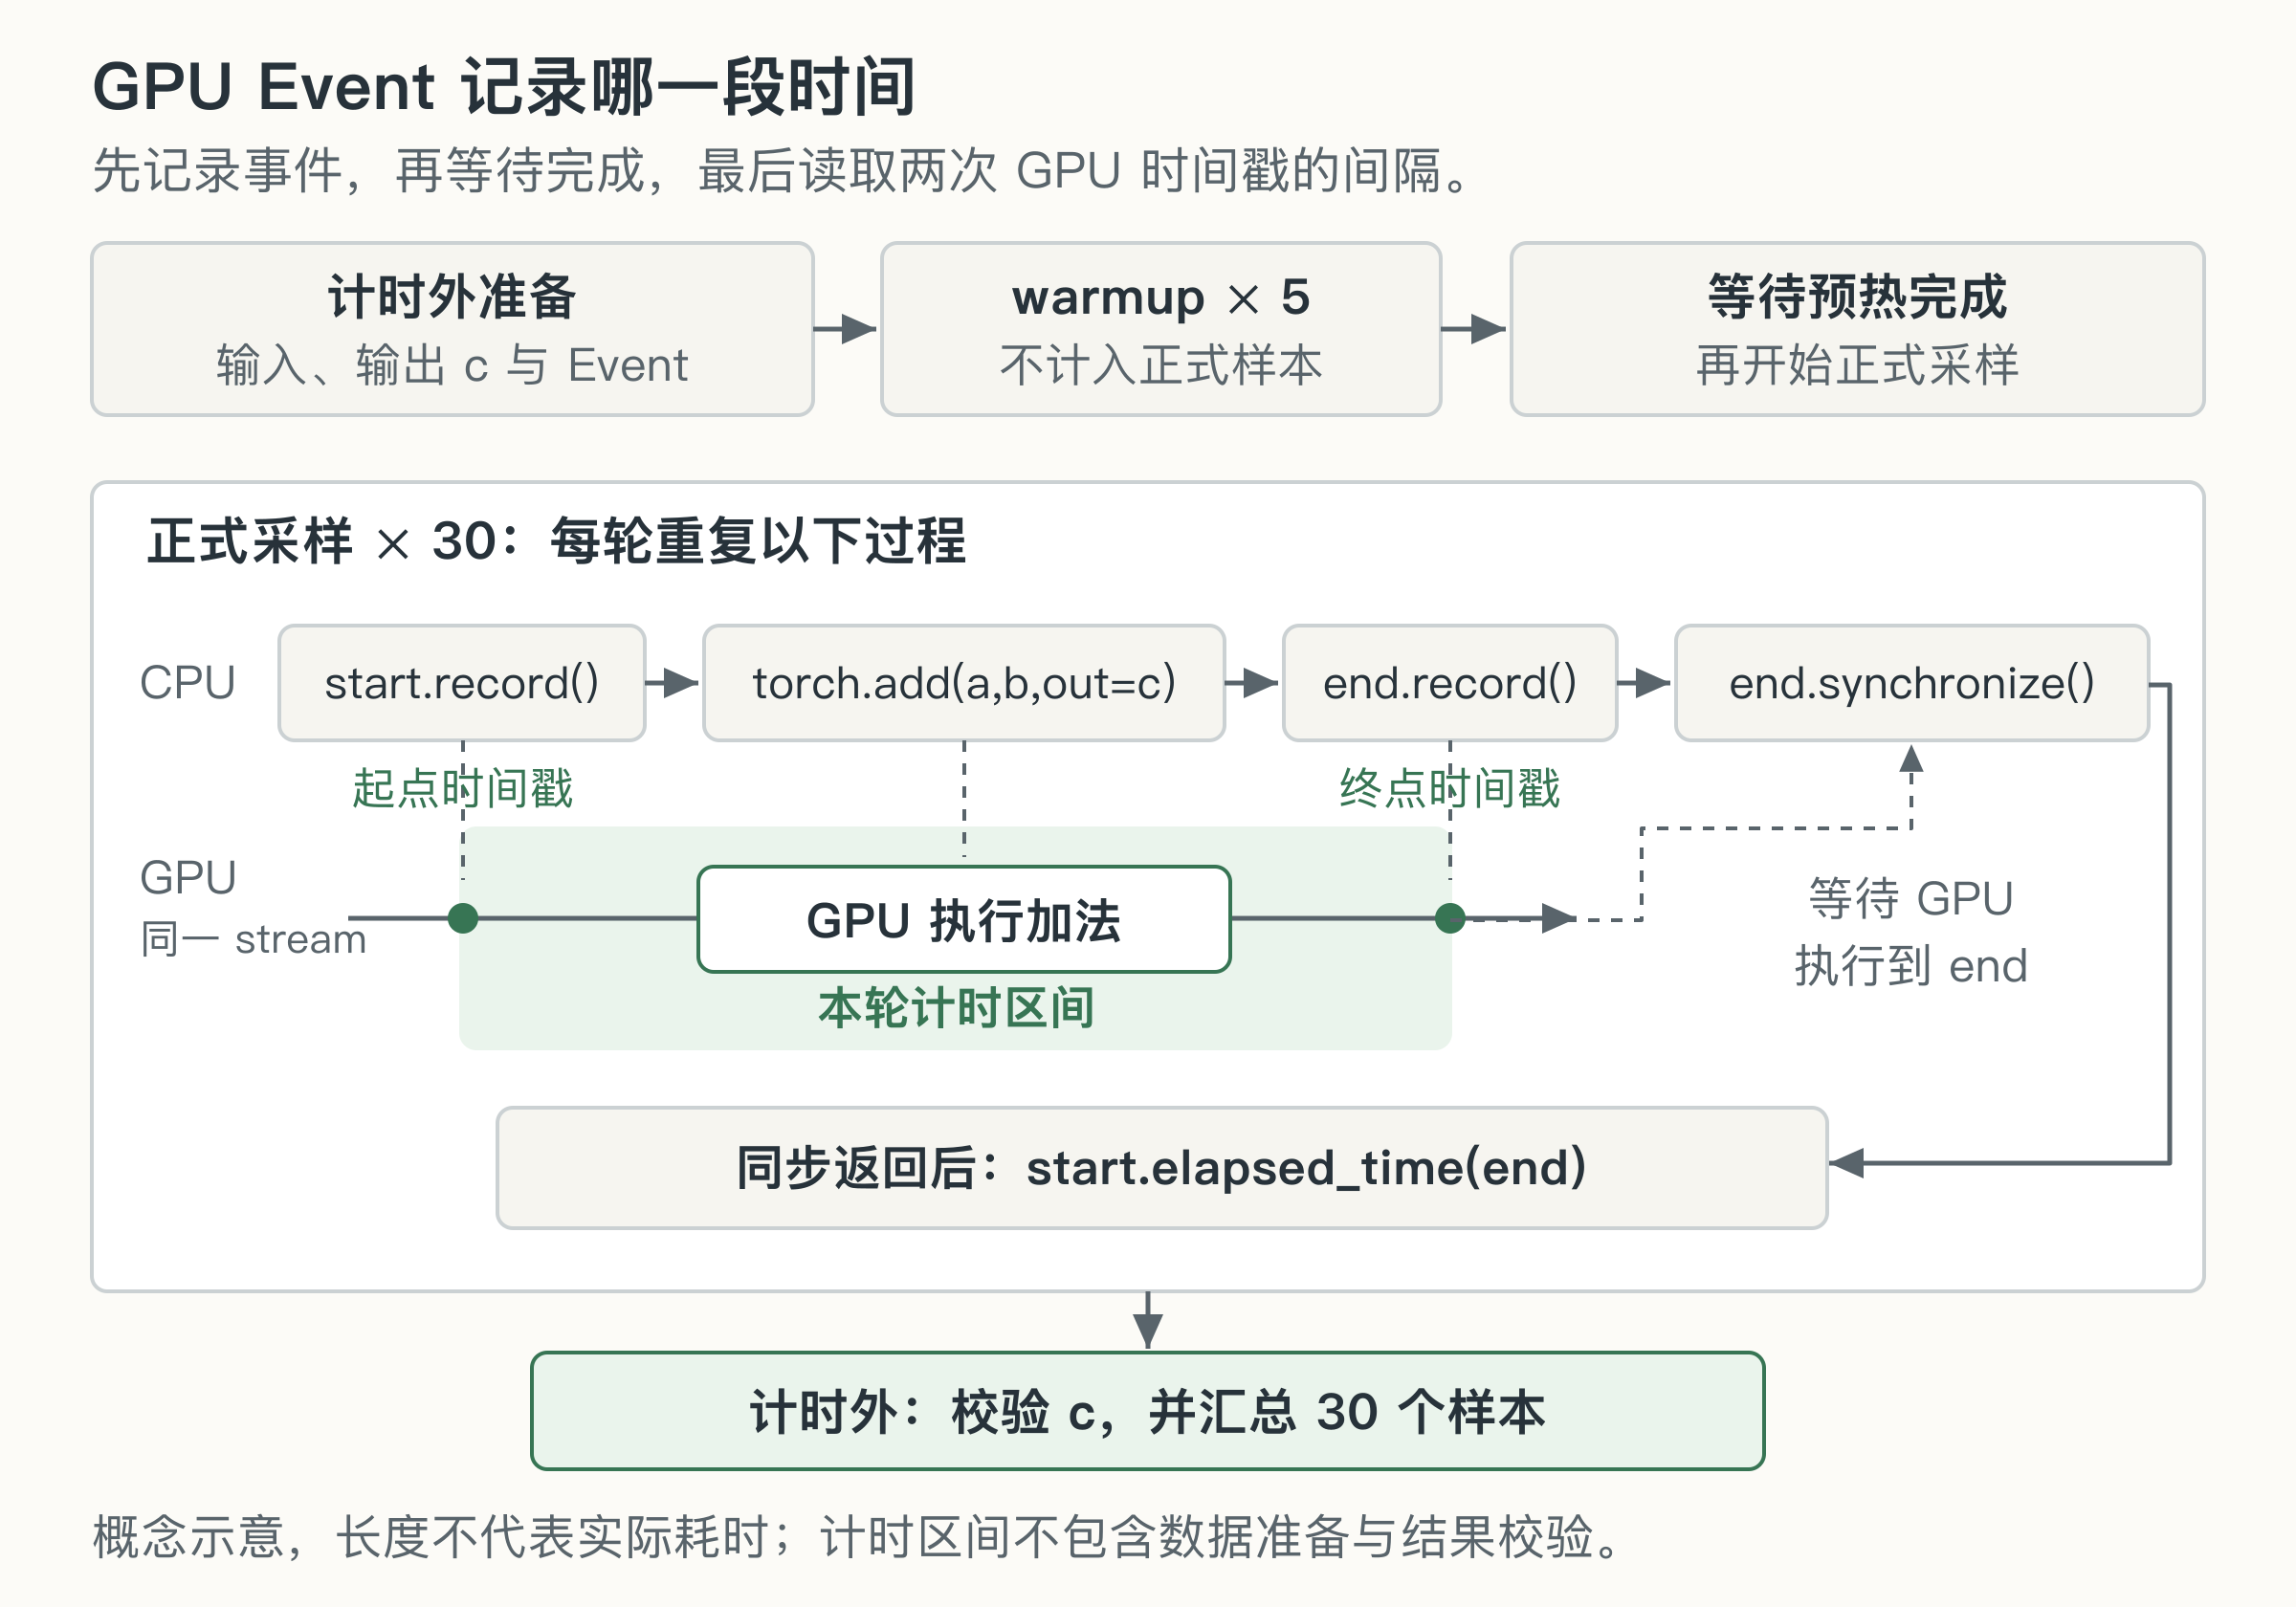

*event 先排队、后执行；读取结束时间前需要等待。*


In [ ]:
%run ../../common/bootstrap.py

import torch
import hello_gpu as gpu
from hello_gpu import learning, profiling
%load_ext hello_gpu
cfg = gpu.settings()
env = gpu.environment()
env


## 5.2 运行一次完整的基准测试

沿用已经理解的向量加法。kernel 源码在本单元；公共包只管理编译和绑定。输入使用固定 seed 的非均匀数据，输出通过全量核对后才进入测量。


In [ ]:
%%hip vector_add --entry vector_add
__global__ void vector_add(const float* a, const float* b, float* c, int n) {
    int64_t i = static_cast<int64_t>(blockIdx.x) * blockDim.x + threadIdx.x;
    if (i < n) c[i] = a[i] + b[i];
}


In [ ]:
N = cfg['n']
a, b = learning.inputs(N, seed=cfg['seed'])
out = torch.empty_like(a)
run = vector_add.prepare(a, b, block=cfg['block'], out=out)
run()
torch.testing.assert_close(out, a + b)


In [ ]:
single = gpu.benchmark(run, label='HIP single', warmup=cfg['warmup'], repeat=cfg['repeat'])
gpu.summary([single])


## 5.3 从准备数据到记录一个样本

`prepare` 提前分配并核对 Tensor 元数据；实际调用仍包含 C++ 校验与启动。下面把计时步骤展开一次，观察 start→运算→end 的关系。初始化 event 放在正式计时之前。


In [ ]:
start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
start.record(); end.record(); end.synchronize()
start.record()
run()
end.record()
end.synchronize()
print('一次 event 区间：', start.elapsed_time(end), 'ms')


多次测量能显示离群点。最小值是本次最快样本，中位数描述中心位置；两者都不保证下一次调用的时间。先看分布，再解释改动。


In [ ]:
gpu.plot_samples(single)


## 5.4 单次样本与批量平均值

用一对 event 包住多次调用，再除以调用数，得到一个批平均值。下面重复测量多批；批平均值之间的分布也不能还原批内各次调用的分布。


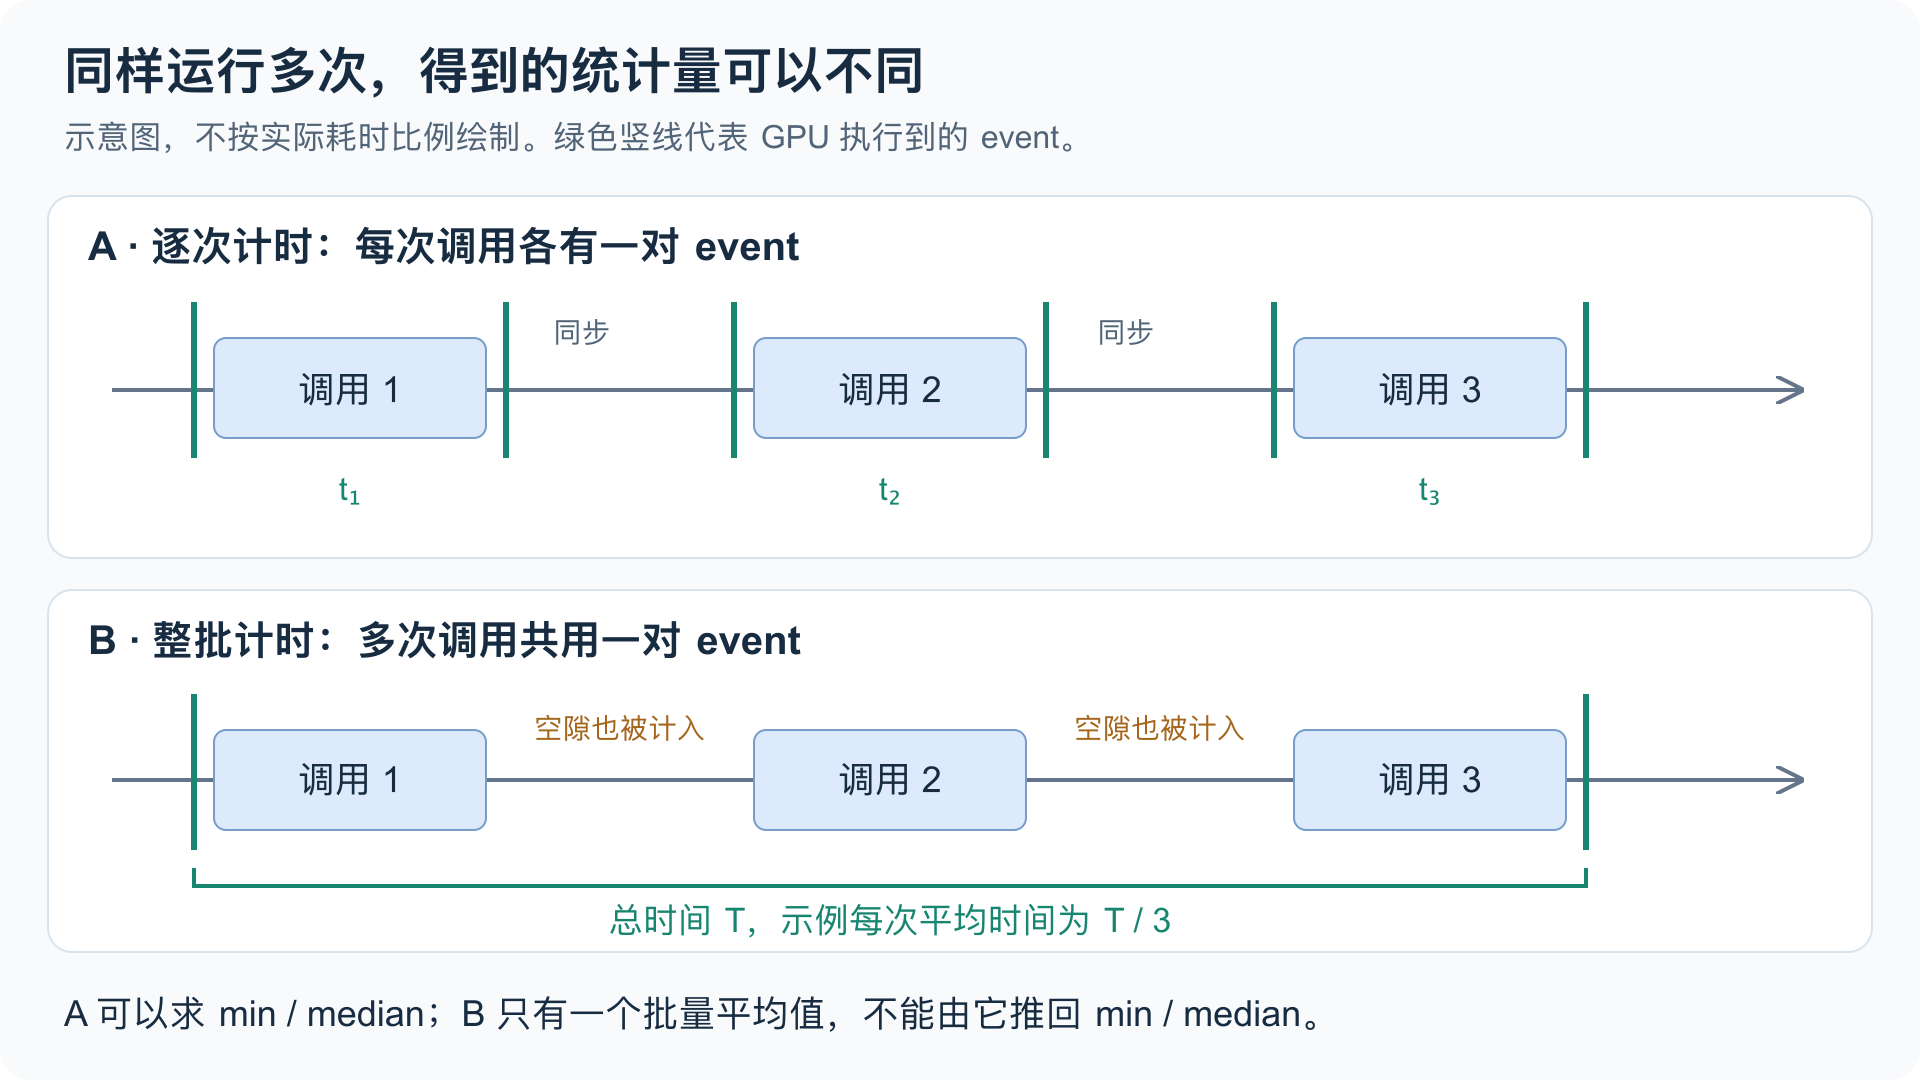

*同一个算子，两种采样边界。*


In [ ]:
batch = gpu.benchmark_batch(run, label='HIP batch mean', batch=20,
                            warmup=cfg['warmup'], repeat=cfg['repeat'])
gpu.summary([single, batch])


In [ ]:
gpu.plot_samples([single, batch])


## 5.5 从时间算出有效带宽

加法的算法字节数是 $3Ns$；复制只有一次读、一次写，是 $2Ns$。GB/s 使用十进制字节。这些是逻辑有效字节，重复输入可能命中缓存，不能据此读取物理显存流量。

接着写一个短 Triton 复制 kernel。它不是用来与加法比较框架优劣，而是让读写总量的系数更清楚。


In [ ]:
import triton
import triton.language as tl
@triton.jit
def copy_kernel(x, y, n, BLOCK: tl.constexpr):
    offsets = tl.program_id(0) * BLOCK + tl.arange(0, BLOCK)
    valid = offsets < n
    tl.store(y + offsets, tl.load(x + offsets, mask=valid, other=0), mask=valid)


In [ ]:
copied = torch.empty_like(a)
def run_copy():
    copy_kernel[(triton.cdiv(a.numel(), 1024),)](a, copied, a.numel(), BLOCK=1024, num_warps=4)
run_copy()
torch.testing.assert_close(copied, a)
copy_time = gpu.benchmark_batch(run_copy, label='Triton copy batch', batch=20,
                               warmup=cfg['warmup'], repeat=cfg['repeat'])
print('加法 GB/s：', 3 * a.numel() * a.element_size() / single.median_ms / 1e6)
print('复制 GB/s：', 2 * a.numel() * a.element_size() / copy_time.median_ms / 1e6)


## 5.6 复测、记录与练习

保留每次样本及其口径。新的输入规模或 dtype 要重新预热；正式计时与 profiling 分开执行。


In [ ]:
timings = gpu.summary([single, batch, copy_time])
launches = {
    'HIP single': {'block': cfg['block'], 'batch': 1},
    'HIP batch mean': {'block': cfg['block'], 'batch': 20},
    'Triton copy batch': {'BLOCK': 1024, 'num_warps': 4,
                          'grid': [triton.cdiv(a.numel(), 1024)], 'batch': 20},
}
record = learning.save_table('part1-profiling/chapter5', timings,
                            config={**cfg, 'n': a.numel(), 'correctness': 'full comparison passed'},
                            kernels=[vector_add], sources={'Triton copy batch': copy_kernel.src},
                            launches=launches)
record


**练习**：把批大小从 20 改为 5，比较批平均值分布；把输入长度加倍，重新校验并测量；说明哪些现象可能由缓存或提交节奏引起，还需要什么证据。

## 本章小结

我们固定了输入、输出分配和采样方式，保留了原始样本，并把字节数与时间换算成逻辑有效带宽。下一章用 profiler 直接观察 kernel dispatch。

## 延伸阅读

- [第6章 notebook](../chapter6/chapter6.ipynb)
- [PyTorch HIP 语义](https://docs.pytorch.org/docs/stable/notes/hip.html)
